<a href="https://colab.research.google.com/github/rajdepot/probnstats/blob/machineLearning/Predictive_modelling_Class_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topic 1: Model Evaluation and Cross-Validation Motivation (1 Hour)

## 1.1 Introduction to Cross-Validation

## Introduction to Cross-Validation

### What is Cross-Validation?
Cross-validation is a statistical method used to evaluate the performance of a model by dividing the dataset into multiple subsets. The model is trained on one subset and validated on the others, ensuring that the performance is not dependent on a particular train-test split.

### Why Use Cross-Validation?
- **Generalization**: Provides a more accurate estimate of model performance on unseen data.
- **Hyperparameter Tuning**: Helps in selecting the optimal number of features or other hyperparameters by testing different configurations on multiple subsets of data.

### Example:
Consider a linear regression model where we want to determine the optimal number of features. Cross-validation can be used to evaluate different feature sets and select the best one.


## 1.2 Cross-Validation for Feature Selection

### The Challenge of Feature Selection
In linear regression, the number of input variables (features) is a hyperparameter. Manually tuning this hyperparameter can be problematic because the model might "see" the test data, leading to biased results.

### Solution: Cross-Validation
Cross-validation splits the data into train and test sets multiple times, ensuring that each subset of data gets a chance to be the validation set. This helps in determining the optimal number of features without risking overfitting.

### Cross-Validation Technique:
1. **K-fold Cross-Validation**: The data is divided into k subsets, and the model is trained k times, each time using a different subset as the validation set.
2. **Manual vs. Automated Tuning**: Automated methods like cross-validation provide more reliable results compared to manual tuning.


In [ ]:
from sklearn.datasets import load_boston
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
import numpy as np

# Load dataset
data = load_boston()
X, y = data.data, data.target


# Define model
model = LinearRegression()

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kf)

# Results
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV score: {np.mean(cv_scores):.3f}")

print(X)
data


Cross-validation scores: [0.66875949 0.7342547  0.70986601 0.77595168 0.68727731]
Mean CV score: 0.715
[[6.3200e-03 1.8000e+01 2.3100e+00 ... 1.5300e+01 3.9690e+02 4.9800e+00]
 [2.7310e-02 0.0000e+00 7.0700e+00 ... 1.7800e+01 3.9690e+02 9.1400e+00]
 [2.7290e-02 0.0000e+00 7.0700e+00 ... 1.7800e+01 3.9283e+02 4.0300e+00]
 ...
 [6.0760e-02 0.0000e+00 1.1930e+01 ... 2.1000e+01 3.9690e+02 5.6400e+00]
 [1.0959e-01 0.0000e+00 1.1930e+01 ... 2.1000e+01 3.9345e+02 6.4800e+00]
 [4.7410e-02 0.0000e+00 1.1930e+01 ... 2.1000e+01 3.9690e+02 7.8800e+00]]


{'data': array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 1.5300e+01, 3.9690e+02,
         4.9800e+00],
        [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9690e+02,
         9.1400e+00],
        [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9283e+02,
         4.0300e+00],
        ...,
        [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
         5.6400e+00],
        [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9345e+02,
         6.4800e+00],
        [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
         7.8800e+00]]),
 'target': array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
        18.9, 21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 18.2, 13.6, 19.6,
        15.2, 14.5, 15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 14.5, 13.2,
        13.1, 13.5, 18.9, 20. , 21. , 24.7, 30.8, 34.9, 26.6, 25.3, 24.7,
        21.2, 19.3, 20. , 16.6, 14.4, 19.4, 19.7, 20.5, 25. , 23.4, 18.9,
        35.4, 24.7, 3

In [ ]:
# Exercise::


In [ ]:
#pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
automobile = fetch_ucirepo(id=10)

# data (as pandas dataframes)
X = automobile.data.features
y = automobile.data.targets

temp = y.copy()

y = X['price']
X = pd.merge(X.iloc[:,1:] , temp, left_index = True, right_index=True)


In [ ]:
X.columns

Index(['highway-mpg', 'city-mpg', 'peak-rpm', 'horsepower',
       'compression-ratio', 'stroke', 'bore', 'fuel-system', 'engine-size',
       'num-of-cylinders', 'engine-type', 'curb-weight', 'height', 'width',
       'length', 'wheel-base', 'engine-location', 'drive-wheels', 'body-style',
       'num-of-doors', 'aspiration', 'fuel-type', 'make', 'normalized-losses',
       'symboling'],
      dtype='object')

# Topic 2: Cross-Validation - Python Demonstration (1 Hour)

## 2.1 K-Fold Cross-Validation

### What is K-Fold Cross-Validation?
K-fold cross-validation is a technique where the dataset is divided into k equally sized folds. The model is trained on k-1 folds and validated on the remaining fold. This process is repeated k times, each time with a different fold as the validation set.

### Benefits of K-Fold Cross-Validation:
- **Robustness**: Provides a more robust estimate of model performance compared to a single train-test split.
- **Efficiency**: Ensures that all data points are used for both training and validation, maximizing the utility of the data.

### Example:
Let's apply K-fold cross-validation to a linear regression model to evaluate its performance.


In [ ]:
# K-Fold Cross-Validation with Linear Regression
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_kfold = cross_val_score(model, X, y, cv=kf)

# Results
print(f"10-Fold Cross-validation scores: {cv_scores_kfold}")
print(f"Mean 10-Fold CV score: {np.mean(cv_scores_kfold):.3f}")


10-Fold Cross-validation scores: [0.75981355 0.60908125 0.76975858 0.71639463 0.61663293 0.79789535
 0.76682601 0.79453027 0.74066667 0.59908146]
Mean 10-Fold CV score: 0.717


## 2.2 Other Cross-Validation Techniques

### Leave-One-Out Cross-Validation (LOO)
- **Explanation**: LOO cross-validation is an extreme case of k-fold cross-validation where k equals the number of data points. Each data point is used once as the validation set, making it computationally expensive but thorough.
- **Use Case**: Useful when the dataset is small, but impractical for large datasets.

### Leave P-Out (LPO) Cross-Validation
- **Explanation**: A generalization of LOO where p data points are left out for validation in each iteration. It provides more flexibility but can be computationally demanding.

### Stratified K-Fold Cross-Validation
- **Explanation**: Ensures that each fold has a representative distribution of the target variable, particularly useful for imbalanced datasets.

### Example:
We will demonstrate LOO cross-validation and compare its results with K-fold cross-validation.


In [ ]:
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

# Define the model
model = LinearRegression()

# Leave-One-Out Cross-Validation
loo = LeaveOneOut()

# Use MSE as the scoring metric
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
cv_scores_loo = cross_val_score(model, X, y, cv=loo, scoring=mse_scorer)

# Since we're using negative MSE, take the absolute value to get the mean MSE
mean_mse_loo = -np.mean(cv_scores_loo)

# Results
print(f"Leave-One-Out CV Mean MSE: {mean_mse_loo:.3f}")

# For comparison with K-Fold (assuming you already have cv_scores_kfold from previous K-Fold cross-validation)
mean_mse_kfold = -np.mean(cv_scores_kfold)

# Difference between LOO and K-Fold
print(f"Difference between LOO and K-Fold CV Mean MSE: {mean_mse_loo - mean_mse_kfold:.3f}")


Leave-One-Out CV Mean MSE: 23.726
Difference between LOO and K-Fold CV Mean MSE: 24.443


# Topic 3: Cross-Validation - Hyperparameter Tuning (1 Hour)

## 3.1 Hyperparameter Tuning with GridSearchCV

### What is Hyperparameter Tuning?
Hyperparameters are settings or configurations external to the model that cannot be learned directly from the training data. Examples include the learning rate in a neural network or the number of features in a linear model. The process of finding the optimal hyperparameters is called hyperparameter tuning.

### Grid Search:
- **Explanation**: Grid search is a brute-force approach to hyperparameter tuning. It systematically tries every combination of hyperparameter values in a specified grid to find the optimal set.
- **Steps**:
  1. **Define the Cross-Validation Scheme**: Choose how the data will be split into training and validation sets (e.g., K-Fold Cross-Validation).
  2. **Define the Hyperparameter Grid**: Specify the range of values for each hyperparameter.
  3. **Perform Grid Search**: Train the model on every combination of hyperparameters and evaluate it using cross-validation.

### Why Negative MSE?
- **Mean Squared Error (MSE)** is a common metric used to evaluate regression models. It measures the average squared difference between the actual and predicted values.
- In `GridSearchCV`, **negative MSE** is used because `GridSearchCV` is designed to maximize the scoring metric. By using the negative MSE, the model that minimizes the MSE will have the highest (least negative) score.


In [ ]:
model

LinearRegression()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameters to tune
param_grid = {
    'fit_intercept': [True, False],
    'normalize': [True, False]
}

# Implement GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=kf, scoring='neg_mean_squared_error')
grid_search.fit(X, y)

# Results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {-grid_search.best_score_:.3f}")


Best Parameters: {'fit_intercept': True, 'normalize': True}
Best Cross-Validation Score: 23.364


## 3.2 Practical Example: Grid Search with Linear Regression

### Hyperparameters in Linear Regression:
- **fit_intercept**: Determines whether the intercept (bias term) should be included in the model.
  - **True**: The model will include an intercept.
  - **False**: The model will not include an intercept, forcing the line to pass through the origin.
- **normalize**: Determines whether the features should be normalized before regression.
  - **True**: The features will be normalized.
  - **False**: The features will be used as-is.

### Example:
We will use `GridSearchCV` to find the optimal values for `fit_intercept` and `normalize` in a linear regression model. We'll evaluate each combination of these hyperparameters using K-Fold Cross-Validation and compare their performances using negative MSE.


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error

# Define the model
model = LinearRegression()

# Define the parameter grid
param_grid = {
    'fit_intercept': [True, False],
    'normalize': [True, False]
}

# Define the scoring metric: using negative MSE
scoring = make_scorer(mean_squared_error, greater_is_better=False)

# Implement GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring=scoring)
grid_search.fit(X, y)

# Results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score (Negative MSE): {grid_search.best_score_:.3f}")


Best Parameters: {'fit_intercept': False, 'normalize': True}
Best Cross-Validation Score (Negative MSE): -34.423


## 3.3 Analyzing Grid Search Results

### Interpreting the Results
After performing grid search, we can analyze the results to determine which combination of hyperparameters gives the best performance. The results can be viewed in two main ways:
1. **Tabular Form**: A DataFrame that shows the performance of each hyperparameter combination.
2. **Graphical Form**: A plot that visualizes the performance across different hyperparameter combinations.

### Example:
We will view the grid search results in a DataFrame and create a plot to visualize how different combinations of `fit_intercept` and `normalize` affect the model's performance.


In [ ]:
grid_search.cv_results_

{'mean_fit_time': array([0.00130525, 0.00109625, 0.        , 0.00059965]),
 'std_fit_time': array([0.0007849 , 0.0006891 , 0.        , 0.00048987]),
 'mean_score_time': array([0.00059392, 0.00070801, 0.00080345, 0.00039723]),
 'std_score_time': array([0.00048505, 0.00065268, 0.000402  , 0.00048657]),
 'param_fit_intercept': masked_array(data=[True, True, False, False],
              mask=[False, False, False, False],
        fill_value='?',
             dtype=object),
 'param_normalize': masked_array(data=[True, False, True, False],
              mask=[False, False, False, False],
        fill_value='?',
             dtype=object),
 'params': [{'fit_intercept': True, 'normalize': True},
  {'fit_intercept': True, 'normalize': False},
  {'fit_intercept': False, 'normalize': True},
  {'fit_intercept': False, 'normalize': False}],
 'split0_test_score': array([-14.99585288, -14.99585288, -16.19351698, -16.19351698]),
 'split1_test_score': array([-32.80452455, -32.80452455, -41.00379151, -41

  param_fit_intercept param_normalize  mean_test_score  rank_test_score
0                True            True       -37.131807                3
1                True           False       -37.131807                4
2               False            True       -34.422842                1
3               False           False       -34.422842                1


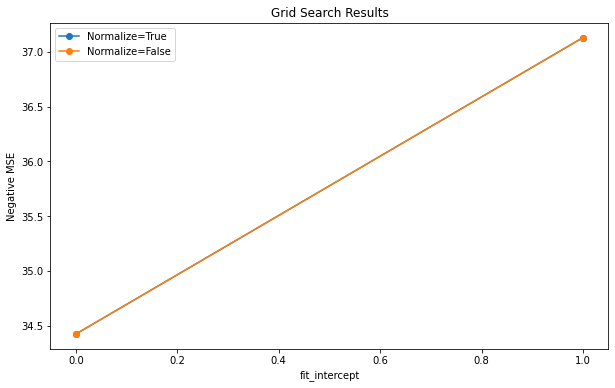

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert the results to a DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

# Display the DataFrame with selected columns
print(cv_results[['param_fit_intercept', 'param_normalize', 'mean_test_score', 'rank_test_score']])

# Plotting the Mean Test Score against the 'fit_intercept' parameter
plt.figure(figsize=(10, 6))
for normalize in [True, False]:
    subset = cv_results[cv_results['param_normalize'] == normalize]
    plt.plot(subset['param_fit_intercept'], -subset['mean_test_score'], label=f'Normalize={normalize}', marker='o')

plt.xlabel('fit_intercept')
plt.ylabel('Negative MSE')
plt.title('Grid Search Results')
plt.legend()
plt.show()


## Final Thoughts

- **Grid Search and Hyperparameter Tuning**: Highlight how GridSearchCV helps in finding the best model configuration without manually experimenting with different hyperparameters.
- **Q&A**: Address any final questions and encourage students to experiment with different models and datasets to solidify their understanding.
